In [27]:
%pip install pandas numpy scikit-learn matplotlib seaborn plotly


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import random
import plotly.express as px
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# Set reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Uploading the data 

In [29]:
df = pd.read_csv("creditcard.csv")
df.head()
df.shape
df.info()

# Check for duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Ensure Class column is integer
df["Class"] = df["Class"].astype(int)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Training and Testing Split for the Model 

In [30]:
X = df.drop(columns=["Class"])
Y = df["Class"]

# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.30, stratify=Y, random_state=RANDOM_SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED
)

print("Fraud rates:")
print("Train:", y_train.mean())
print("Val:", y_val.mean())
print("Test:", y_test.mean())

Fraud rates:
Train: 0.0016665995327479256
Val: 0.0016682722808336662
Test: 0.0016682722808336662


Evaluation Functions 

In [31]:
def evaluate(y_true, y_pred):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

def confusion(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "TP": int(((y_pred==1)&(y_true==1)).sum()),
        "FP": int(((y_pred==1)&(y_true==0)).sum()),
        "FN": int(((y_pred==0)&(y_true==1)).sum()),
        "TN": int(((y_pred==0)&(y_true==0)).sum()),
    }

Creating the model 

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.model_selection import GridSearchCV
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# best model parameters
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        solver='lbfgs',
        max_iter=5000
    ),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)
best_params = grid_search.best_params_
print("Best parameters:", best_params)

model = LogisticRegression(
    solver='lbfgs',
    max_iter=5000,
    C=best_params['C'],
    class_weight=best_params['class_weight']
)
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

eval_train = evaluate(y_train, y_train_pred)
eval_val = evaluate(y_val, y_val_pred)
eval_test = evaluate(y_test, y_test_pred)

print("Train Eval:", eval_train)
print("Val Eval:", eval_val)
print("Test Eval:", eval_test)



Best parameters: {'C': 1, 'class_weight': None}
Train Eval: {'precision': 0.8666666666666667, 'recall': 0.6283987915407855, 'f1': 0.7285464098073555}
Val Eval: {'precision': 0.8333333333333334, 'recall': 0.49295774647887325, 'f1': 0.6194690265486725}
Test Eval: {'precision': 0.8461538461538461, 'recall': 0.6197183098591549, 'f1': 0.7154471544715447}


Visualization of the Model Performance 


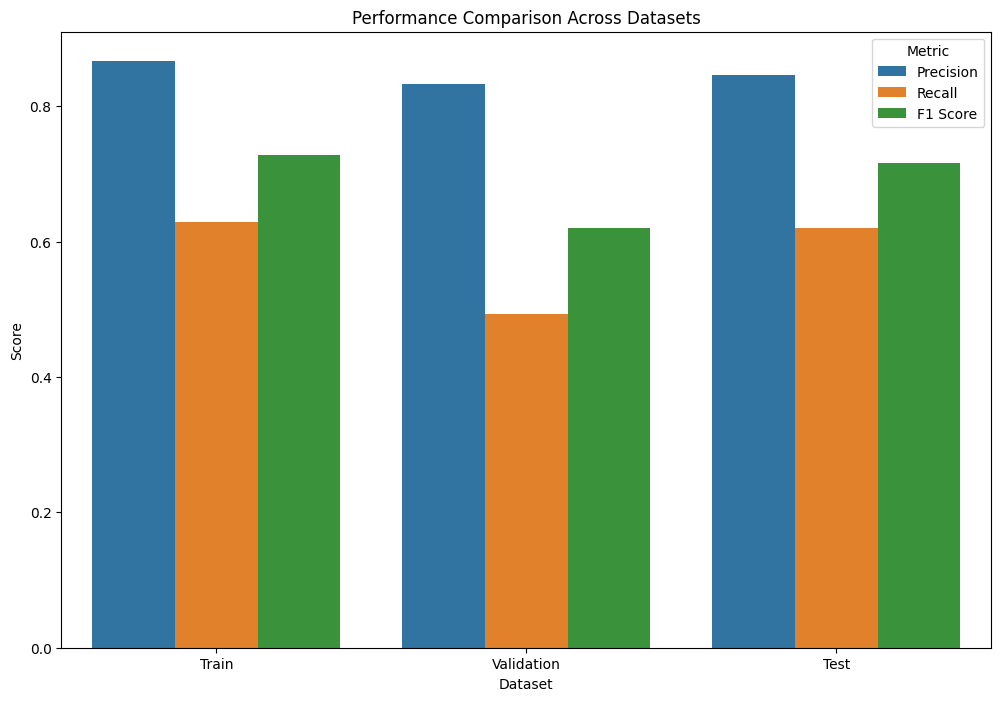

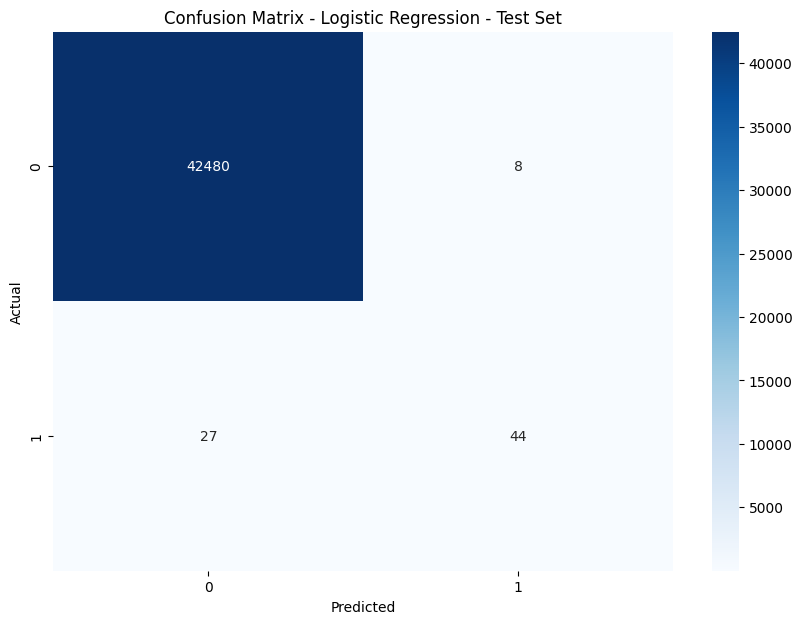

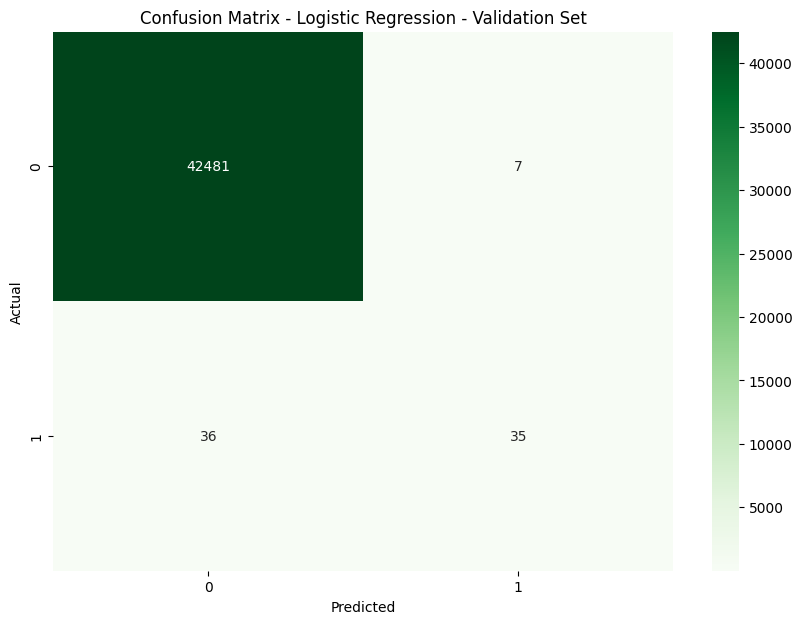

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': 'variable=Precision<br>Dataset=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': 'Precision',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'Precision',
              'offsetgroup': 'Precision',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['Train', 'Validation', 'Test'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': 'vLu7u7u76z+rqqqqqqrqPzuxEzuxE+s/', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'hovertemplate': 'variable=Recall<br>Dataset=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': 'Recall',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'Recall',
              'offsetgroup': 'Recall',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['Train', 'Validation', 'Test'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': 'X29QyNcb5D+U8dulnozfP5d6Mn671OM/', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'hovertemplate': 'variable=F1 Score<br>Dataset=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': 'F1 Score',
              'marker': {'color': '#00cc96', 'pattern': {'shape': ''}},
              'name': 'F1 Score',
              'offsetgroup': 'F1 Score',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['Train', 'Validation', 'Test'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': 'rrR3j0BQ5z8LKz21sNLjP+UWT27x5OY/', 'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'legend': {'title': {'text': 'variable'}, 'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Performance Comparison Across Datasets'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Dataset'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'value'}}}
})

In [55]:
metrics_df = pd.DataFrame({
            "Dataset": ["Train", "Validation", "Test"],
            "Precision": [eval_train['precision'], eval_val['precision'], eval_test['precision']],
            "Recall": [eval_train['recall'], eval_val['recall'], eval_test['recall']],
            "F1 Score": [eval_train['f1'], eval_val['f1'], eval_test['f1']]
        })

plt.figure(figsize=(12, 8))
performance_across_all_sets = sns.barplot(data=metrics_df.melt(id_vars=["Dataset"], var_name="Metric", value_name="Score"),
                                          x="Dataset", y="Score", hue="Metric")
plt.title("Performance Comparison Across Datasets")
sns.move_legend(performance_across_all_sets, "upper right")
plt.show()
# confusion matrices

# testing set 
from sklearn.metrics import confusion_matrix
cm_test= confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels= model.classes_,
            yticklabels= model.classes_)
plt.title("Confusion Matrix - Logistic Regression - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# validation set 
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
            xticklabels= model.classes_,
            yticklabels= model.classes_)
plt.title("Confusion Matrix - Logistic Regression - Validation Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ig 